<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelima/blob/main/Praktikum_5_3_MG_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PRAKTIKUM 5.3: FILTER NON-LINEAR UNTUK SALT-AND-PEPPER NOISE


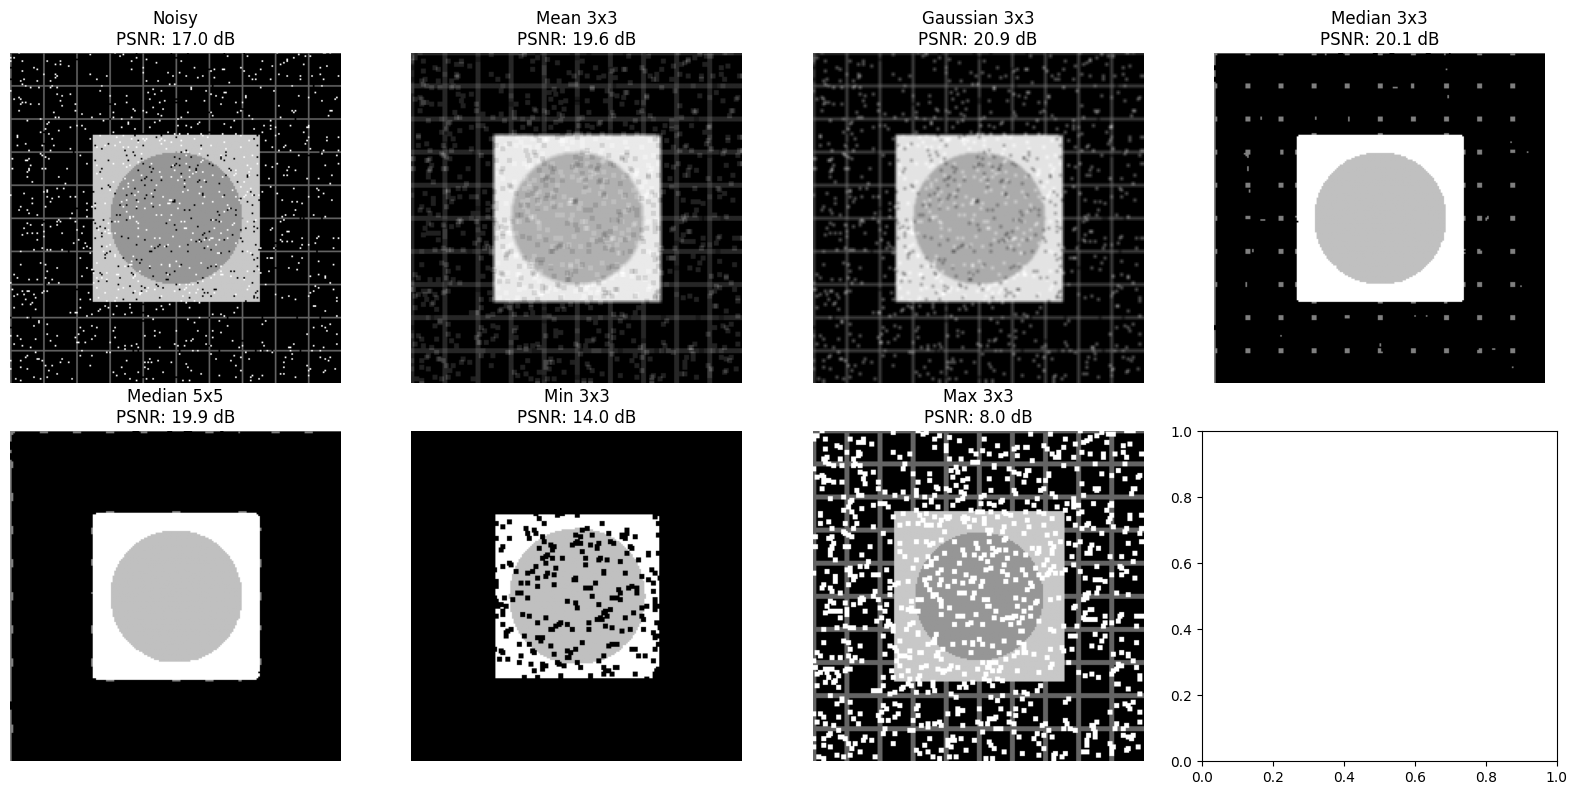


ANALYSIS OF NON-LINEAR FILTERS FOR SALT-AND-PEPPER NOISE
----------------------------------------------------------------------
Observation:
1. Median filter performs best for salt-and-pepper noise
2. Linear filters (mean, Gaussian) blur the image and don't remove noise effectively
3. Min filter removes salt noise but darkens the image
4. Max filter removes pepper noise but brightens the image


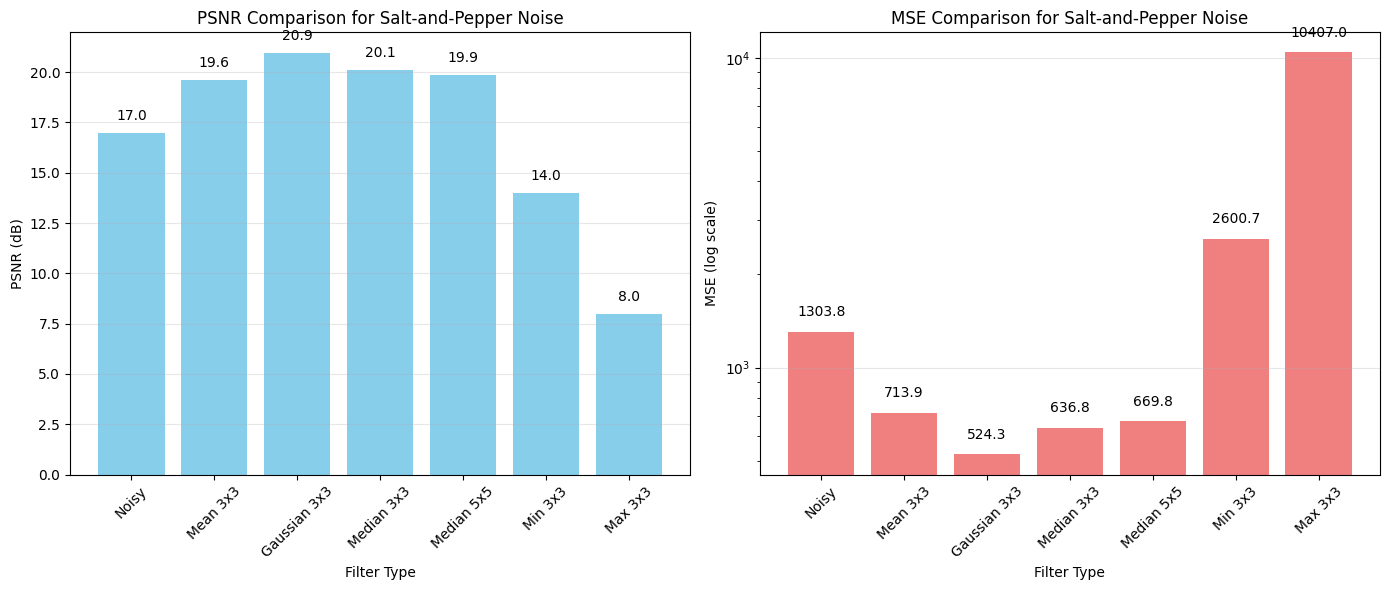

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def nonlinear_filters_demo():
    """
    Demonstrasi filter non-linear untuk salt-and-pepper noise
    """
    print("\nPRAKTIKUM 5.3: FILTER NON-LINEAR UNTUK SALT-AND-PEPPER NOISE")
    print("=" * 60)

    # Create clean image with texture
    clean_img = np.zeros((200, 200), dtype=np.uint8)

    # Add texture pattern
    for i in range(0, 200, 20):
        cv2.line(clean_img, (i, 0), (i, 199), 100, 1)
        cv2.line(clean_img, (0, i), (199, i), 100, 1)

    cv2.rectangle(clean_img, (50, 50), (150, 150), 200, -1)
    cv2.circle(clean_img, (100, 100), 40, 150, -1)

    # Add salt-and-pepper noise
    def add_salt_pepper_noise(image, prob=0.05):
        noisy = image.copy()
        total_pixels = image.size

        # Salt noise
        num_salt = int(total_pixels * prob / 2)
        salt_coords = [np.random.randint(0, i-1, num_salt) for i in image.shape]
        noisy[salt_coords[0], salt_coords[1]] = 255

        # Pepper noise
        num_pepper = int(total_pixels * prob / 2)
        pepper_coords = [np.random.randint(0, i-1, num_pepper) for i in image.shape]
        noisy[pepper_coords[0], pepper_coords[1]] = 0

        return noisy

    noisy_img = add_salt_pepper_noise(clean_img, prob=0.05)

    # Apply different filters
    filters = {
        'Noisy': lambda x: x,
        'Mean 3x3': lambda x: cv2.blur(x, (3, 3)),
        'Gaussian 3x3': lambda x: cv2.GaussianBlur(x, (3, 3), 0),
        'Median 3x3': lambda x: cv2.medianBlur(x, 3),
        'Median 5x5': lambda x: cv2.medianBlur(x, 5),
        'Min 3x3': lambda x: cv2.erode(x, np.ones((3, 3))),
        'Max 3x3': lambda x: cv2.dilate(x, np.ones((3, 3)))
    }

    # Apply filters and calculate metrics
    results = []

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for idx, (filter_name, filter_func) in enumerate(filters.items()):
        filtered_img = filter_func(noisy_img)

        # Calculate metrics
        mse = np.mean((clean_img.astype(float) - filtered_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        results.append({
            'filter': filter_name,
            'mse': mse,
            'psnr': psnr
        })

        # Display
        axes[idx].imshow(filtered_img, cmap='gray')
        axes[idx].set_title(f'{filter_name}\nPSNR: {psnr:.1f} dB')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Analysis of results
    print("\nANALYSIS OF NON-LINEAR FILTERS FOR SALT-AND-PEPPER NOISE")
    print("-" * 70)
    print("Observation:")
    print("1. Median filter performs best for salt-and-pepper noise")
    print("2. Linear filters (mean, Gaussian) blur the image and don't remove noise effectively")
    print("3. Min filter removes salt noise but darkens the image")
    print("4. Max filter removes pepper noise but brightens the image")

    # Visual comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # PSNR comparison
    filter_names = [r['filter'] for r in results]
    psnr_values = [r['psnr'] for r in results]

    bars1 = ax1.bar(filter_names, psnr_values, color='skyblue')
    ax1.set_xlabel('Filter Type')
    ax1.set_ylabel('PSNR (dB)')
    ax1.set_title('PSNR Comparison for Salt-and-Pepper Noise')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')

    for bar, psnr in zip(bars1, psnr_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{psnr:.1f}', ha='center', va='bottom')

    # MSE comparison (log scale)
    mse_values = [r['mse'] for r in results]
    bars2 = ax2.bar(filter_names, mse_values, color='lightcoral')
    ax2.set_xlabel('Filter Type')
    ax2.set_ylabel('MSE (log scale)')
    ax2.set_title('MSE Comparison for Salt-and-Pepper Noise')
    ax2.set_yscale('log')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')

    for bar, mse in zip(bars2, mse_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{mse:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return results

nonlinear_filter_results = nonlinear_filters_demo()